# Problem statement

** to predict fashion classes **

## Imporing Libraries

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Mounting Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing Dataset

In [4]:
fashion_train_df=pd.read_csv("/content/drive/My Drive/Colab Notebooks/Datasets/fashion-mnist_train.csv")
fashion_test_df=pd.read_csv("/content/drive/My Drive/Colab Notebooks/Datasets/fashion-mnist_test.csv")


##  Summerize dataset

In [5]:
fashion_train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Creating Training and testing arrays

In [ ]:
training=np.array(fashion_train_df,dtype='float64')
testing=np.array(fashion_test_df,dtype='float64')

In [ ]:
print(training)

[[2. 0. 0. ... 0. 0. 0.]
 [9. 0. 0. ... 0. 0. 0.]
 [6. 0. 0. ... 0. 0. 0.]
 ...
 [8. 0. 0. ... 0. 0. 0.]
 [8. 0. 0. ... 0. 0. 0.]
 [7. 0. 0. ... 0. 0. 0.]]


In [ ]:
training.shape

(60000, 785)

##  Lets view some images

Text(0.5, 1.0, '2.0')

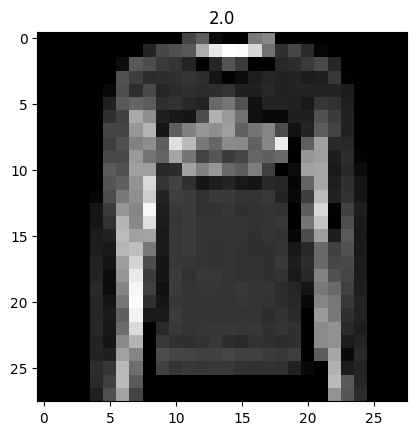

In [ ]:
i=np.random.randint(0,60000)
plt.imshow(training[i,1:].reshape((28,28)),cmap='grey')
plt.title(training[i,0])

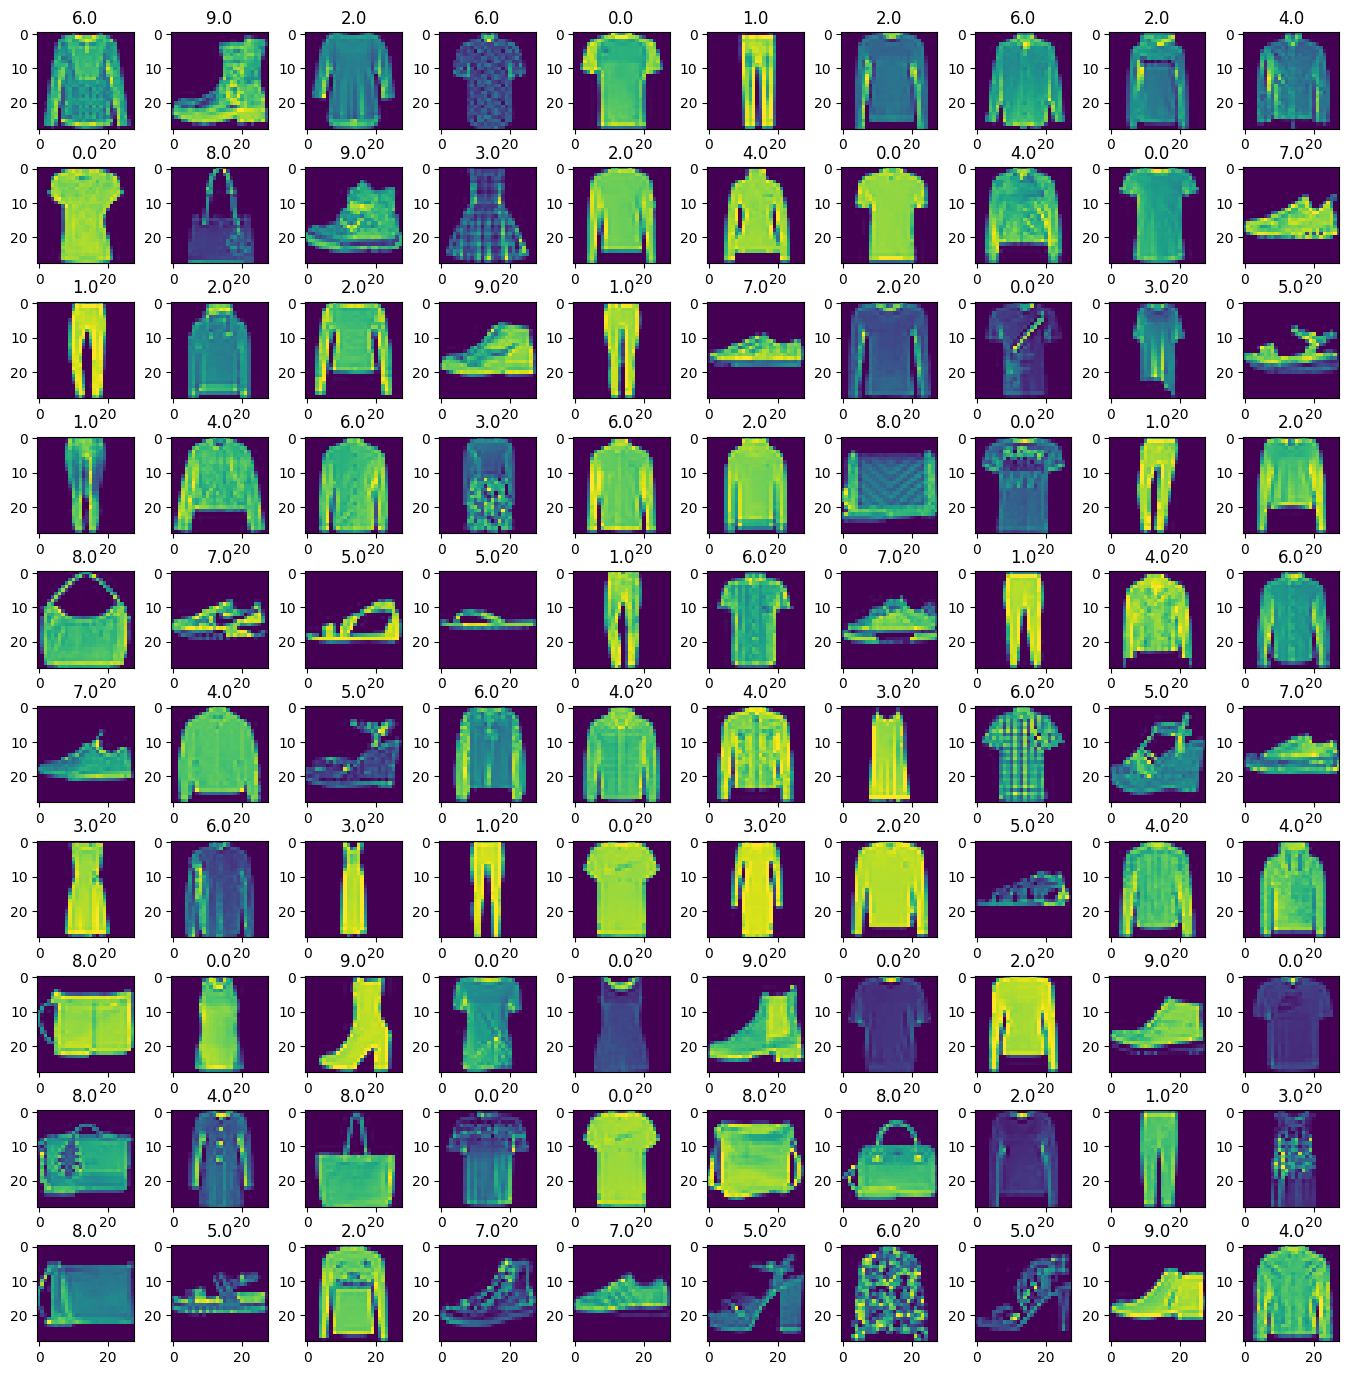

In [ ]:
#to show multiple images
l_grid=10
w_grid=10

figure,axes=plt.subplots(l_grid,w_grid,figsize=(17,17))
axes=axes.ravel() # flatten 15X15 matrix into 1 D array
for ax in axes:
  index=np.random.randint(0,60000)
  ax.imshow(training[index,1:].reshape((28,28)))
  ax.set_title(training[index,0])
  # ax.axis("off")
plt.subplots_adjust(hspace=0.4)
plt.show()



##  prepareing dataset

In [ ]:
x_train=training[:,1:]
y_train=training[:,0]

x_test=testing[:,1:]
y_test=testing[:,0]


In [ ]:
x_train.shape

(60000, 784)

In [ ]:
#reshaping to provide input to cnn model
x_train=x_train.reshape(x_train.shape[0],*(28,28,1)) #here 1 represents channel
x_test=x_test.reshape(x_test.shape[0],*(28,28,1))

In [ ]:
x_train.shape

(60000, 28, 28, 1)

## Creating Model and Train

In [ ]:
from tensorflow.keras import models,layers

In [ ]:
cnn=models.Sequential()
#conv1
cnn.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
cnn.add(layers.MaxPooling2D(2,2))

#conv2
cnn.add(layers.Conv2D(64,(3,3),activation='relu'))
cnn.add(layers.MaxPooling2D(2,2))

#flatten layer
cnn.add(layers.Conv2D(32,(3,3),activation='relu'))
cnn.add(layers.Flatten())

#hidden layer
cnn.add(layers.Dense(units=64,activation='relu'))

#ouput
cnn.add(layers.Dense(units=10,activation="softmax"))

cnn.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 3, 3, 32)            │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 288)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 56,426 (220.41 KB)

 Trainable params: 56,426 (220.41 KB)

 Non-trainable params: 0 (0.00 B)

In [1]:
#compilation
cnn.compile(optimizer="Adam",loss="sparse_categorical_crossentropy",metrics=['accuracy'])

NameError: name 'cnn' is not defined

In [ ]:
epoch_hist=cnn.fit(x_train,y_train,epochs=20,batch_size=512)

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.4384 - loss: 3.1670
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8093 - loss: 0.5211
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8397 - loss: 0.4391
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8587 - loss: 0.3884
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8680 - loss: 0.3621
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8784 - loss: 0.3360
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8836 - loss: 0.3158
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8941 - loss: 0.2907
Epoch 9/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8944 - loss: 0.2871 
Epoch 10/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8984 - loss: 0.2751
Epoch 11/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9061 - loss: 0.2583
Epoch 12/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/

In [ ]:
y_pred=cnn.predict(x_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
y_pred

array([[9.9660838e-01, 2.4817226e-10, 3.3677527e-05, ..., 1.1204459e-12,
        3.8201529e-06, 1.5111615e-13],
       [6.7023493e-08, 9.9982089e-01, 1.8875227e-08, ..., 7.3990793e-07,
        2.9894842e-05, 1.2447063e-06],
       [1.0604738e-02, 1.6045823e-10, 9.7576118e-01, ..., 9.4258169e-08,
        6.4882516e-07, 2.2979398e-07],
       ...,
       [4.8681806e-14, 7.2679574e-14, 4.8295341e-13, ..., 1.6254916e-13,
        1.0000000e+00, 1.2318263e-19],
       [9.5602428e-04, 5.5388251e-04, 1.0504289e-04, ..., 9.2248403e-05,
        9.9769056e-01, 1.4322023e-04],
       [3.5118381e-03, 7.9293752e-01, 3.8903938e-03, ..., 2.8583640e-05,
        2.2109621e-03, 1.4948702e-04]], dtype=float32)

In [ ]:
predicted=np.argmax(y_pred,axis=1)
predicted

array([0, 1, 2, ..., 8, 8, 1])

In [ ]:
y_test

array([0., 1., 2., ..., 8., 8., 1.])

## Evaluating

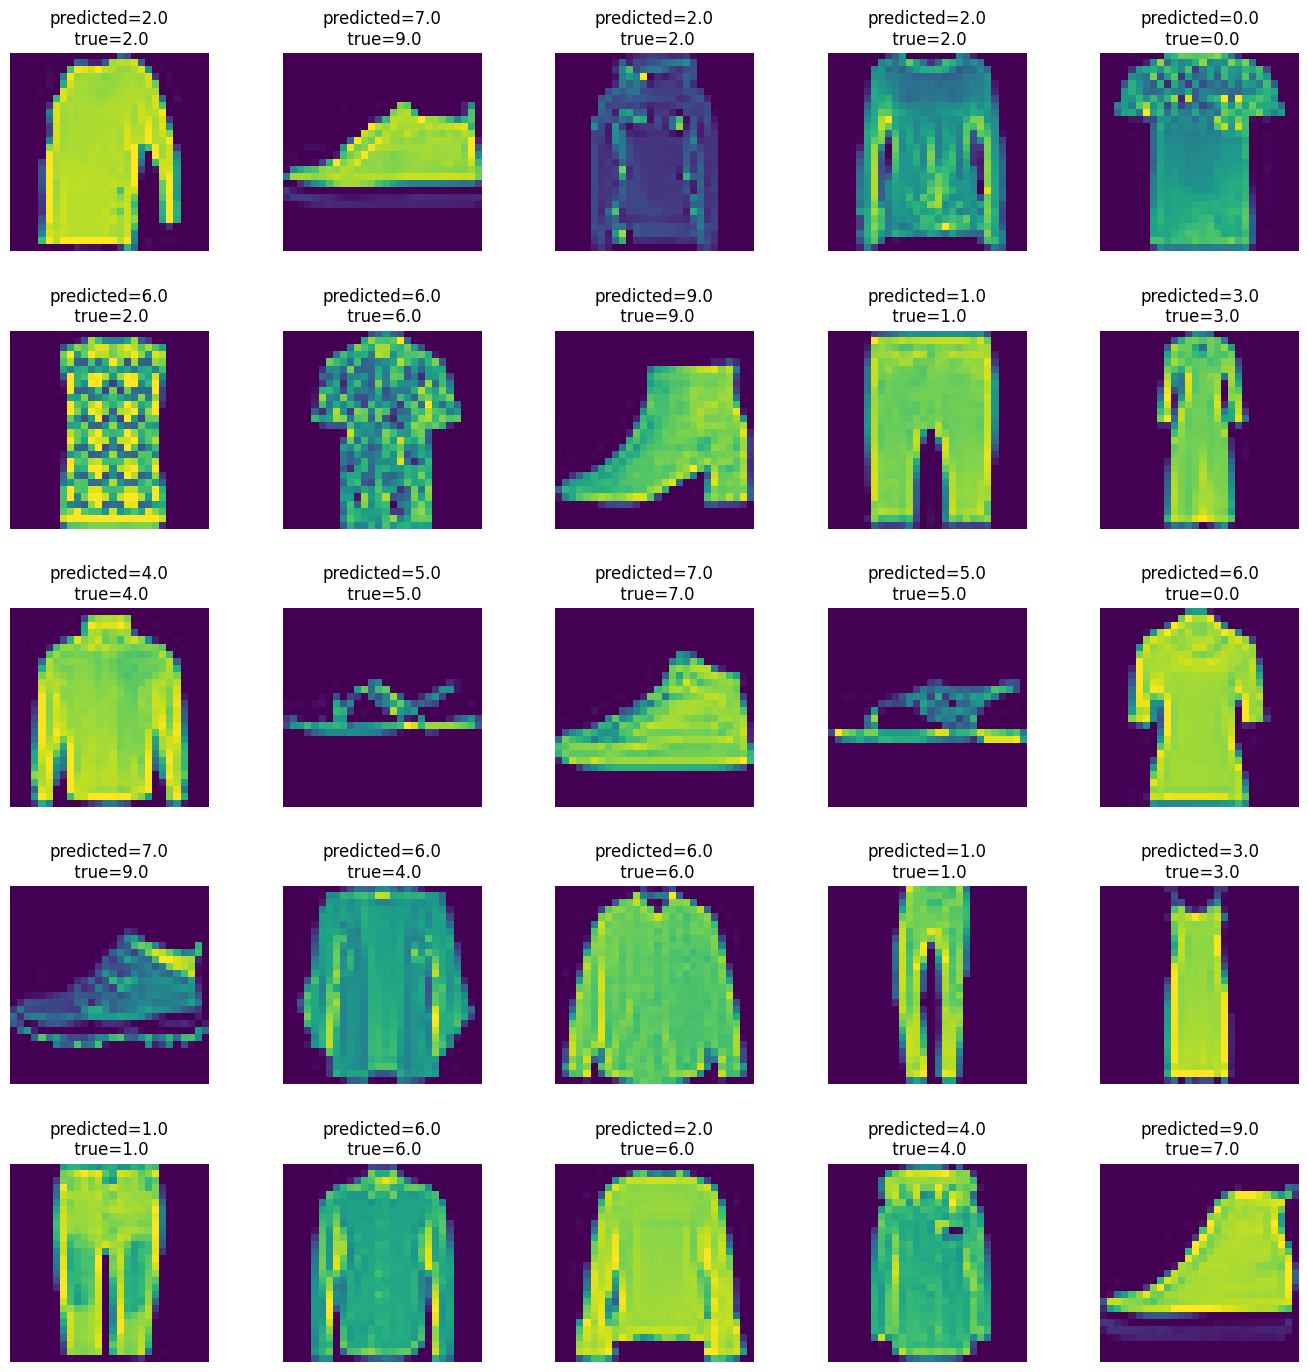

In [ ]:
l_grid=5
w_grid=5

figure,axes=plt.subplots(l_grid,w_grid,figsize=(17,17))
axes=axes.ravel() # flatten 15X15 matrix into 1 D array
for ax in axes:
  index=np.random.randint(0,x_test.shape[0])
  ax.imshow(x_test[index].reshape((28,28)))
  ax.set_title("predicted={:0.1f}\n true={:0.1f}".format(predicted[index],y_test[index]))
  ax.axis("off")
plt.subplots_adjust(hspace=0.4)
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [ ]:
print(confusion_matrix(y_test,predicted))
print(accuracy_score(y_test,predicted))

[[874   1  18  14   1   1  80   1  10   0]
 [  2 978   3   7   1   1   6   0   2   0]
 [ 20   1 860  10  36   0  65   0   8   0]
 [ 29   4   7 911  18   1  27   0   3   0]
 [  1   0  90  27 789   1  90   0   2   0]
 [  2   1   0   0   0 967   0  16   1  13]
 [122   3  79  29  42   0 711   0  14   0]
 [  0   0   0   0   0   7   0 954   0  39]
 [  2   0   5   0   2   2   7   0 982   0]
 [  0   0   0   0   0   3   0  30   1 966]]
0.8992
